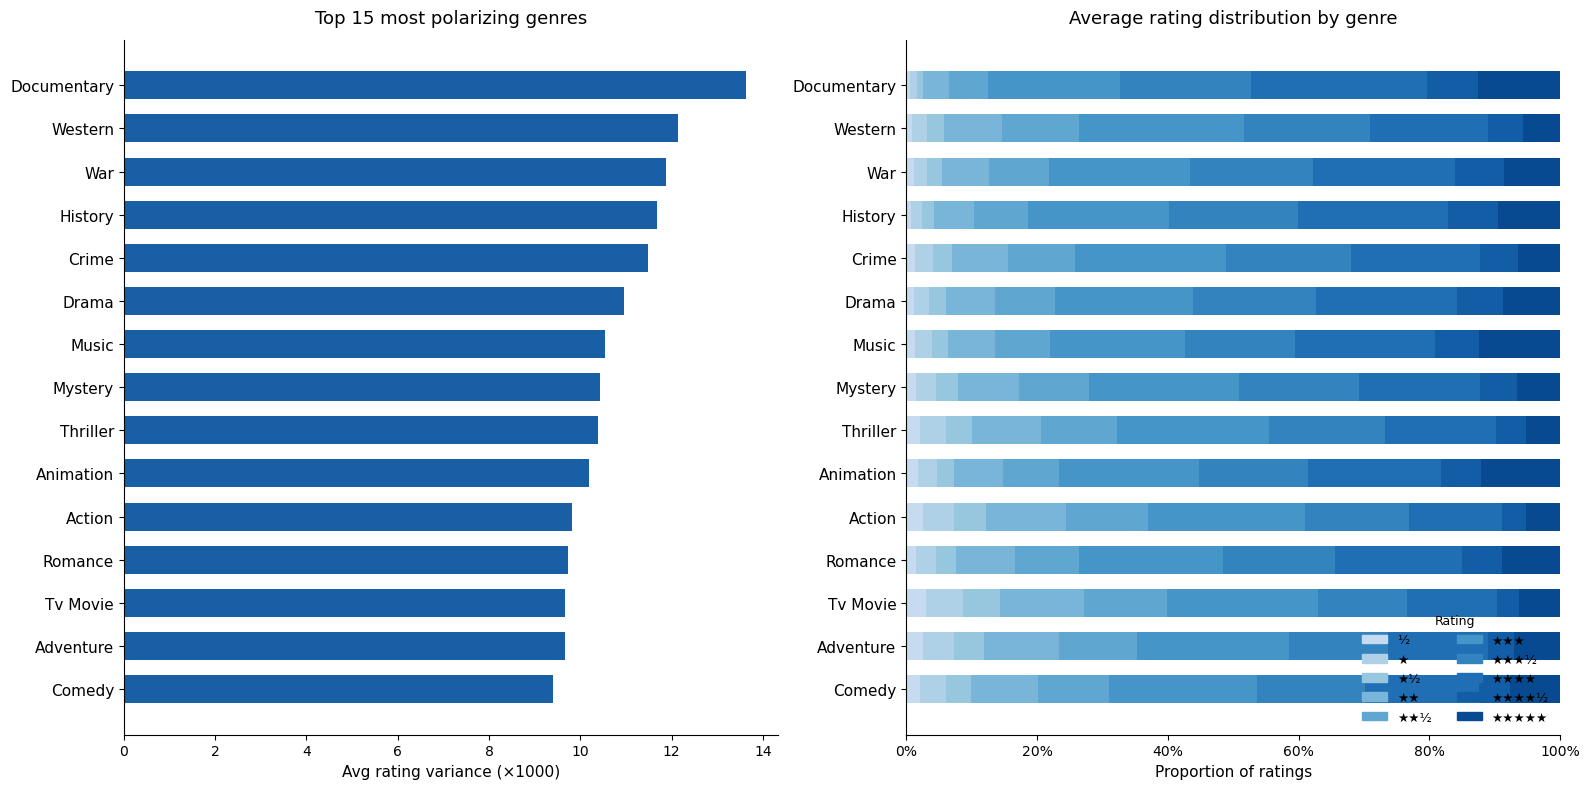

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ast
import pandas as pd

# Read data
df = pd.read_csv("Movie_Data_File.csv")

star_cols = [
    "½", "★", "★½", "★★", "★★½",
    "★★★", "★★★½", "★★★★", "★★★★½", "★★★★★"
]

# Remove rows without genre
df = df.dropna(subset=["Genres"])

# Genres are comma-separated so split and explode
df["Genres"] = df["Genres"].apply(ast.literal_eval)
df = df.explode("Genres")

# Clean genres formatting
df["Genres"] = (
    df["Genres"]
    .str.strip()
    .str.title()
)

# Calculate total ratings per film
df["Total_Ratings_Calc"] = df[star_cols].sum(axis=1)

# Convert star counts into proportions
for col in star_cols:
    df[col + "_prop"] = df[col] / df["Total_Ratings_Calc"]

prop_cols = [col + "_prop" for col in star_cols]



# Compute variance across rating proportions (polarization metric)
df["rating_variance"] = df[prop_cols].var(axis=1)

# Average polarization per genre
genre_polarization = (
    df.groupby("Genres")["rating_variance"]
    .mean()
    .sort_values(ascending=False)
)

# Average rating distribution per genre (mean proportion per star level)
genre_dist = (
    df.groupby("Genres")[prop_cols]
    .mean()
)

# Show only top 15 most polarized genres
top_n = 15
top_genres = genre_polarization.head(top_n)
top_genres_scaled = (top_genres * 1000).sort_values(ascending=True)

# Align distribution to same genre order
top_dist = genre_dist.loc[top_genres_scaled.index]



# Single blue color for polarization bars
BAR_COLOR = "#185FA5"

# Blue gradient for stacked rating distribution (light -> dark)
n_stars = len(star_cols)
cmap = plt.cm.Blues
stack_colors = [cmap(0.25 + 0.65 * i / (n_stars - 1)) for i in range(n_stars)]

star_labels = ["½", "★", "★½", "★★", "★★½", "★★★", "★★★½", "★★★★", "★★★★½", "★★★★★"]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.subplots_adjust(wspace=0.35)

genres_ordered = top_genres_scaled.index.tolist()
y_pos = np.arange(len(genres_ordered))

# --- Left panel: polarization variance ---
ax1 = axes[0]
ax1.barh(y_pos, top_genres_scaled.values, color=BAR_COLOR, height=0.65)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(genres_ordered, fontsize=11)
ax1.set_xlabel("Avg rating variance (×1000)", fontsize=11)
ax1.set_title("Top 15 most polarizing genres", fontsize=13, fontweight="normal", pad=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="x", labelsize=10)

# --- Right panel: rating distribution (100% stacked) ---
ax2 = axes[1]
dist_vals = top_dist[prop_cols].values  # shape: (15, 10)

lefts = np.zeros(len(genres_ordered))
for i, (label, color) in enumerate(zip(star_labels, stack_colors)):
    widths = dist_vals[:, i]
    ax2.barh(y_pos, widths, left=lefts, color=color, height=0.65, label=label)
    lefts += widths

ax2.set_yticks(y_pos)
ax2.set_yticklabels(genres_ordered, fontsize=11)
ax2.set_xlabel("Proportion of ratings", fontsize=11)
ax2.set_title("Average rating distribution by genre", fontsize=13, fontweight="normal", pad=12)
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(axis="x", labelsize=10)

# Legend for star ratings
handles = [
    plt.Rectangle((0, 0), 1, 1, color=stack_colors[i], label=star_labels[i])
    for i in range(n_stars)
]
ax2.legend(
    handles=handles,
    title="Rating",
    loc="lower right",
    fontsize=9,
    title_fontsize=9,
    frameon=False,
    ncol=2
)

plt.tight_layout()
plt.show()